In [30]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.integrate as scp

# Input parameters
# Nacelle
Mass_RNA = 350000             # [kg]

# tower
H_Tower = 80                    # [m]
m_Tower = 347500/H_Tower                   # [kg/m]
D_avg=(6.5 + 3.87) / 2        # [m]
t_avg = (0.027 + 0.019) / 2       # [m]
A = np.pi * D_avg * t_avg          # [m2]
I = np.pi * D_avg**3 * t_avg / 8  # [m4]
E = 210e9                       # [N/m2]
EI_Tower = E * I                 # [N.m2]
EA_Tower = E * A                 # [N]


#spar 
M_spar = 7466330                # [kg]
I_spar = 4229230000                 # [kg.m2]

D_spar = 9.4    #Spar diameter [m]
r_spar = D_spar / 2    #Spar radius [m]


#wave parameters
H_Wave = 6.0 #[m]
T_wave = 10.0 #[s]
T_total = 200.0  #[s]

#time vector
dt= 0.05
T = np.arange(0, T_total, dt)
nT = len(T)




discretize the domain 

In [31]:
# Define node coordinates
 
n_elem = 40 
n_nodes = n_elem + 1

tower_nodes = np.array([[0, y] for y in np.linspace(0, H_Tower, n_nodes)])

spar_node = np.array([[0, -99.9]])

NodeCoord = np.vstack([spar_node, tower_nodes])
nNode = len(NodeCoord)

In [32]:
# Define elements (and their properties
#             NodeLeft    NodeRight          m         EA        EI
Elements = []
for i in range (1, n_nodes):
    Elements.append([i, i+1, m_Tower, EA_Tower, EI_Tower])

Elements = np.array(Elements)
nElem = len(Elements)


plot the structure 

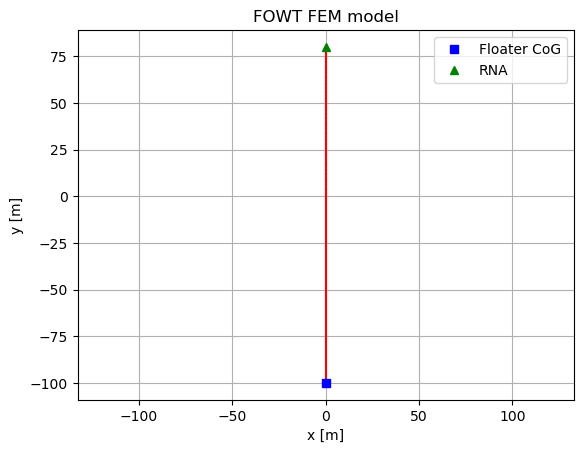

In [33]:
plt.figure()
for iElem in np.arange(0, nElem):
    NodeLeft = int(Elements[iElem][0])-1
    NodeRight = int(Elements[iElem][1])-1
    plt.plot([NodeCoord[NodeLeft][0], NodeCoord[NodeRight][0]], [NodeCoord[NodeLeft][1], NodeCoord[NodeRight][1]], 'r')

plt.plot(NodeCoord[0][0], NodeCoord[0][1], 'bs', label='Floater CoG')
plt.plot(NodeCoord[-1][0], NodeCoord[-1][1], 'g^', label='RNA')
plt.legend()
plt.axis('equal')
plt.grid()
plt.xlabel('x [m]')
plt.ylabel('y [m]')
plt.title('FOWT FEM model')
plt.show()

Shape functions: 

In [34]:
nDof = 3*nNode              # 3 Degrees of freedom per node
K = np.zeros((nDof, nDof))
M = np.zeros((nDof, nDof))

In [35]:
for iElem in range(nElem):
    # Get the nodes of the elements
    NodeLeft = int(Elements[iElem][0])-1
    NodeRight = int(Elements[iElem][1])-1

    m = Elements[iElem][2]
    EA = Elements[iElem][3]
    EI = Elements[iElem][4]

    x1,y1 = NodeCoord[NodeLeft]
    x2,y2 = NodeCoord[NodeRight]
    L = np.sqrt((x2-x1)**2 + (y2-y1)**2)

    #elemental stiffness matrix

    Ke = np.array([
            [ EA/L,           0,          0, -EA/L,           0,          0],
            [    0,  12*EI/L**3,  6*EI/L**2,     0, -12*EI/L**3,  6*EI/L**2],
            [    0,   6*EI/L**2,    4*EI/L,      0,  -6*EI/L**2,    2*EI/L ],
            [-EA/L,           0,          0,  EA/L,           0,          0],
            [    0, -12*EI/L**3, -6*EI/L**2,    0,  12*EI/L**3, -6*EI/L**2],
            [    0,   6*EI/L**2,    2*EI/L,     0,  -6*EI/L**2,    4*EI/L ]
        ])
    
    #elemental mass matrix 
    Me = m * L / 420 * np.array([
        [140,          0,         0,  70,          0,         0],
        [  0,        156,    22*L,    0,         54,    -13*L ],
        [  0,       22*L,   4*L**2,   0,       13*L,  -3*L**2 ],
        [ 70,          0,         0, 140,          0,         0],
        [  0,         54,     13*L,   0,        156,    -22*L ],
        [  0,      -13*L,  -3*L**2,   0,      -22*L,   4*L**2 ]
    ])

    # Get the degrees of freedom that correspond to each node
    Dofs_Left = 3*(NodeLeft) + np.arange(0, 3)
    Dofs_Right = 3*(NodeRight) + np.arange(0, 3)
    nodes = np.append(Dofs_Left, Dofs_Right)

    # Assemble the matrices at the correct place
    for i in np.arange(0, 6):
        for j in np.arange(0, 6):
            K[nodes[i], nodes[j]] += Ke[i, j]
            M[nodes[i], nodes[j]] += Me[i, j]

#add floater
M[0, 0] += M_spar
M[1, 1] += M_spar
M[2, 2] += I_spar


#add RNA point mass
M[3*n_nodes, 3*n_nodes] += Mass_RNA
M[3*n_nodes+1, 3*n_nodes+1] += Mass_RNA


In [36]:
print("Mass matrix M:")
print(M)
print("Stiffness matrix K:")
print(K)


Mass matrix M:
[[7.61097688e+06 0.00000000e+00 0.00000000e+00 ... 0.00000000e+00
  0.00000000e+00 0.00000000e+00]
 [0.00000000e+00 7.62750795e+06 2.27074930e+06 ... 0.00000000e+00
  0.00000000e+00 0.00000000e+00]
 [0.00000000e+00 2.27074930e+06 4.27047506e+09 ... 0.00000000e+00
  0.00000000e+00 0.00000000e+00]
 ...
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 ... 3.50000000e+05
  0.00000000e+00 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 ... 0.00000000e+00
  3.50000000e+05 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 ... 0.00000000e+00
  0.00000000e+00 0.00000000e+00]]
Stiffness matrix K:
[[7.87553881e+08 0.00000000e+00 0.00000000e+00 ... 0.00000000e+00
  0.00000000e+00 0.00000000e+00]
 [0.00000000e+00 3.18227773e+06 1.58954773e+08 ... 0.00000000e+00
  0.00000000e+00 0.00000000e+00]
 [0.00000000e+00 1.58954773e+08 1.05863879e+10 ... 0.00000000e+00
  0.00000000e+00 0.00000000e+00]
 ...
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 ... 0.00000000e+

Text(0.5, 1.0, 'Stiffness matrix')

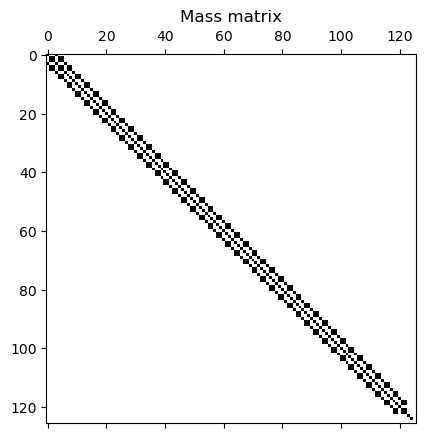

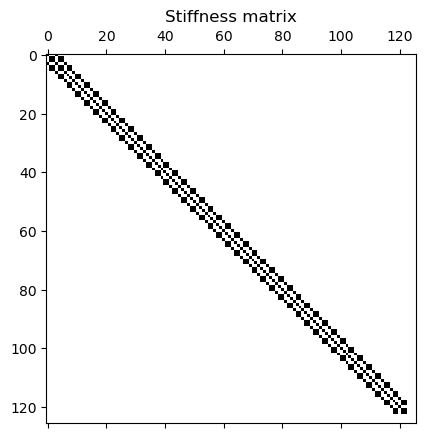

In [37]:
# Look at the matrix structure
plt.figure()
plt.spy(M)
plt.title("Mass matrix")
plt.figure()
plt.spy(K)
plt.title("Stiffness matrix")

In [43]:
#mooring 
K_moor_surge = 41853           # [N/m]
K_moor_heave = 0              # [N/m]
K_moor_pitch = 0              # [N.m/rad]

#hydrostatic stiffness

rho_water = 1025 # [kg/m3]
gravity = 9.81 # [m/s2]
pi = 3.141592

# hydrostatic restoring stiffness
# Substructure Definitions
r_s = 4.7  # Substructure Radius, assumed constant throughout
A_spar = pi * r_s**2  # Cross-sectional area of the substructure
L_spar = 120 + 10  # Spar Buoy Length
rho_spar = M_spar / (A_spar * L_spar)  # Substructure density, assuming uniform

draft_s = 120
submerged_volume_s = A_spar * draft_s
KBuoyancy_s = draft_s / 2
J_sub = 1/2 * pi * r_spar**4
BM_s = J_sub / submerged_volume_s
KGravity_s = L_spar / 2
GM_s = KBuoyancy_s + BM_s - KGravity_s

K_hydro_heave  = rho_water * gravity * A_spar

K_hydro_pitch =   rho_water * gravity * submerged_volume_s * GM_s  #[N/m]


print("Hydrostatic stiffness in heave: ", K_hydro_heave, "N/m")
print("Hydrostatic stiffness in pitch: ", K_hydro_pitch, "N.m/rad")

Hydrostatic stiffness in heave:  697811.8994422201 N/m
Hydrostatic stiffness in pitch:  -410979807.2359927 N.m/rad
